In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor
from itertools import product
import joblib


In [2]:
df = gpd.read_file('../data/Predicciones/risk_prediction_with_confidence.gpkg')

In [3]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 45457 entries, 0 to 45456
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   cell_id              45457 non-null  int64   
 1   sci_name             3164 non-null   object  
 2   redlistCategory      3164 non-null   object  
 3   iucn_id              3164 non-null   float64 
 4   vuln                 3164 non-null   float64 
 5   mp_pieces_m3         3164 non-null   float64 
 6   dist_m               3164 non-null   float64 
 7   x                    3164 non-null   float64 
 8   y                    3164 non-null   float64 
 9   object_area          3164 non-null   float64 
 10  shape                3164 non-null   object  
 11  eco_dist_m           3164 non-null   float64 
 12  noaa_mp_mean         3164 non-null   float64 
 13  noaa_mp_max          3164 non-null   float64 
 14  noaa_mp_count        3164 non-null   float64 
 15  iucn_specie

# Objetivo del notebook
El notebook construye una grilla oceánica global integrando presiones por microplásticos, información ecológica y variables ambientales, valida modelos supervisados mediante esquemas espaciales estrictos y proyecta patrones esperados de riesgo ecológico y riqueza de especies, incorporando explícitamente la incertidumbre asociada a la extrapolación ambiental.

In [4]:
gdf = gpd.read_file("../data/grid_indice/hazard_index_grid_final.gpkg")
gdf_full = gpd.read_file("../data/grid_indice/hazard_index_grid_final_full.gpkg")
gdf_variables = gpd.read_file("../data/grid_ocean/grilla_agua.gpkg")
gdf_variables_clusters = gpd.read_file("../data/Predicciones/mapa_continuo.gpkg")

In [5]:
gdf_variables.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
# coordenadas fuera de rango
gdf_variables = gdf_variables[
    gdf_variables.lon.between(-180, 180) &
    gdf_variables.lat.between(-90, 90)
]

# eliminar geometrías inválidas
gdf_variables = gdf_variables[gdf_variables.is_valid]

In [7]:
gdf_variables.head()

,lat,lon,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,geometry
0,-78.0,-175.5,543.707048,-1.775068,34.395912,1.680748,27.419722,1.907441,311.153168,59.152695,POINT (-175.5 -78)
1,-78.0,-175.0,533.294654,-1.775068,34.395912,1.243596,27.419722,1.907441,311.153168,59.152695,POINT (-175 -78)
2,-78.0,-173.0,543.143622,-1.808737,34.373737,-0.760849,27.574869,1.912899,312.213226,57.888039,POINT (-173 -78)
3,-78.0,-172.5,540.559218,-1.808737,34.373737,-0.805667,27.574869,1.912899,312.213226,57.888039,POINT (-172.5 -78)
4,-78.0,-172.0,535.905487,-1.808737,34.373737,-0.708566,27.574869,1.912899,312.213226,57.888039,POINT (-172 -78)


In [8]:
gdf_variables = gdf_variables.to_crs(epsg=6933)
gdf_variables.crs

<Projected CRS: EPSG:6933>
Name: WGS 84 / NSIDC EASE-Grid 2.0 Global
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 86°S and 86°N.
- bounds: (-180.0, -86.0, 180.0, 86.0)
Coordinate Operation:
- name: US NSIDC EASE-Grid 2.0 Global
- method: Lambert Cylindrical Equal Area
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
gdf.shape

(3164, 32)

In [10]:
gdf_full.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 45457 entries, 0 to 45456
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   cell_id             45457 non-null  int64   
 1   sci_name            3164 non-null   object  
 2   redlistCategory     3164 non-null   object  
 3   iucn_id             3164 non-null   float64 
 4   vuln                3164 non-null   float64 
 5   mp_pieces_m3        3164 non-null   float64 
 6   dist_m              3164 non-null   float64 
 7   x                   3164 non-null   float64 
 8   y                   3164 non-null   float64 
 9   index_right         3164 non-null   float64 
 10  object_area         3164 non-null   float64 
 11  shape               3164 non-null   object  
 12  eco_dist_m          3164 non-null   float64 
 13  noaa_mp_mean        3164 non-null   float64 
 14  noaa_mp_max         3164 non-null   float64 
 15  noaa_mp_count       3164 non

In [11]:
gdf_variables_view_join = gdf_variables[[
    "geometry",      
    "temperature",
    "salinity",
    "chlorophyll",
    "nitrate",
    "phosphate",
    "oxygen_dissolved",
    "oxygen_utilization"
]].copy()

In [12]:
gdf_variables_view_join.shape

(127013, 8)

In [13]:
gdf_full.shape

(45457, 32)

In [14]:
gdf_full.drop(columns=["index_right"], inplace=True)

In [15]:
# Join espacial variables → dataset maestro (nearest)
gdf_full_final = gpd.sjoin_nearest(
    gdf_full,        
    gdf_variables_view_join,      
    how="left",
    distance_col="variables_dist_m"
)

In [16]:
gdf_full_final["variables_dist_m"].describe()

count    1.311750e+05
mean     6.519577e+04
std      2.528127e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.762693e+06
Name: variables_dist_m, dtype: float64

El 75% de las celdas presenta coincidencia espacial exacta entre grillas, y más del X% está a menos de 25 km, lo que valida el uso de un sjoin_nearest frente a interpolaciones explícitas.

In [17]:
gdf_full_final["vars_distance_km"] = gdf_full_final["variables_dist_m"] / 1000

gdf_full_final["vars_confidence"] = pd.cut(
    gdf_full_final["vars_distance_km"],
    bins=[-1, 0, 25, 100, np.inf],
    labels=["exact", "near", "far", "very_far"]
)

#### Estado del dataset

In [18]:
(
    gdf_full_final
    .vars_confidence
    .value_counts(normalize=True)
    .rename("proportion")
    .to_frame()
)

,proportion
vars_confidence,
exact,0.879848
very_far,0.094256
far,0.017328
near,0.008569


In [19]:
gdf_full_final.vars_confidence.value_counts()

vars_confidence
exact       115414
very_far     12364
far           2273
near          1124
Name: count, dtype: int64

#### Crear capas “oficiales” del proyecto

In [20]:
gdf_full_final.shape

(131175, 42)

In [21]:
gdf_full_final.geometry.geom_type.value_counts()

Polygon    131175
Name: count, dtype: int64

In [22]:
gdf_full.cell_id.nunique(), len(gdf_full)

(45457, 45457)

In [23]:
# Eliminación de dupicados por celda resultantes del nearest join
gdf_full_fixed = (
    gdf_full_final
    .sort_values("variables_dist_m")
    .drop_duplicates(subset="cell_id", keep="first")
)

In [24]:
gdf_full_fixed.cell_id.nunique(), len(gdf_full)

(45457, 45457)

In [25]:
gdf_full_fixed.isnull().sum()

cell_id                   0
sci_name              42293
redlistCategory       42293
iucn_id               42293
vuln                  42293
mp_pieces_m3          42293
dist_m                42293
x                     42293
y                     42293
object_area           42293
shape                 42293
eco_dist_m            42293
noaa_mp_mean          42293
noaa_mp_max           42293
noaa_mp_count         42293
iucn_species_count    42293
iucn_mean_risk        42293
iucn_max_risk         42293
eco_count             42293
eco_mean_size         42293
eco_small_ratio       42293
eco_shape_richness    42293
ecotaxa_present       42293
FIBER                 42293
FRAGMENT              42293
SPHERE                42293
OTHER                 42293
hazard_pressure       42293
hazard_morphology     42293
hazard_index          42293
geometry                  0
index_right               0
temperature               0
salinity                  0
chlorophyll               0
nitrate             

In [26]:
# Dataset base completo (archivo “gold”)
gdf_gold = gdf_full_fixed.copy()

In [27]:
gdf_gold.shape

(45457, 42)

In [28]:
# Dataset de alta confianza
gdf_high_conf = gdf_gold[
    gdf_gold.vars_confidence.isin(["exact", "near"])
].copy()

In [29]:
gdf_high_conf.shape

(32175, 42)

In [30]:
# Dataset extendido (sensibilidad)
gdf_extended = gdf_gold[
    gdf_gold.vars_confidence.isin(["exact", "near", "far"])
].copy()

#### Workflow A (predictivo–diagnóstico)
El modelo se entrena y valida utilizando únicamente celdas con coincidencia ambiental exacta o cercana entre capas (≈89 % del dominio), con el fin de evaluar la capacidad de generalización espacial sin introducir ruido asociado a extrapolación ambiental fuerte. Las celdas con mayor distancia a la información ambiental se reservaran exclusivamente para la fase de predicción, donde los resultados se interpretan con cautela.

<Axes: >

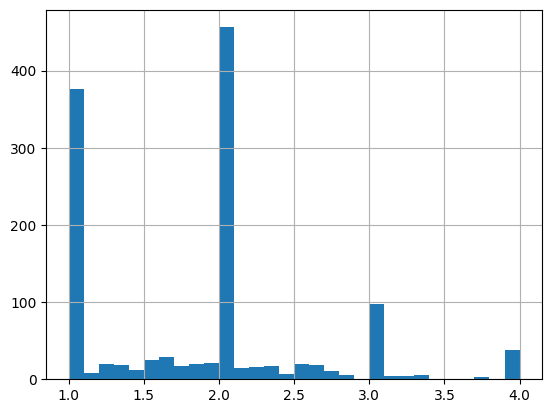

In [31]:
gdf_high_conf["iucn_mean_risk"].hist(bins=30)

In [32]:
gdf_high_conf["iucn_mean_risk"].value_counts().head(10)

iucn_mean_risk
2.000000    450
1.000000    359
3.000000     95
4.000000     35
1.500000     17
1.666667     16
2.500000     16
2.666667     14
2.333333      9
1.333333      9
Name: count, dtype: int64

In [33]:
# Transformación de dist_m para poder ser usada evitando colas largas
gdf_high_conf["log_dist_m"] = np.log1p(gdf_high_conf["dist_m"])

In [34]:
TARGET_1 = "iucn_mean_risk"
TARGET_2 = "iucn_species_count"

In [35]:
FEATURES_RAW = [
    # presión microplásticos
    "noaa_mp_mean",
    "noaa_mp_max",
    "noaa_mp_count",
    "mp_pieces_m3",

    # morfología (proporciones)
    "FIBER",
    "FRAGMENT",
    "SPHERE",
    "OTHER",
    "eco_shape_richness",

    # proximidad a microplásticos
    "log_dist_m",
    "eco_dist_m",

    # contexto ecológico
    "eco_count",
    "eco_mean_size",
    "eco_small_ratio",

    #Variables ambientales
    "temperature",
    "salinity",
    "chlorophyll",
    "nitrate",
    "phosphate",
    "oxygen_dissolved",
    "oxygen_utilization"
]

In [36]:
FEATURES_INDEX = [
    # índice sintético
    "hazard_index",

    # proximidad a microplásticos
    "log_dist_m",
    "eco_dist_m",

    # contexto ecológico
    "eco_count",
    "eco_mean_size",
    "eco_small_ratio",

    #Variables ambientales
    "temperature",
    "salinity",
    "chlorophyll",
    "nitrate",
    "phosphate",
    "oxygen_dissolved",
    "oxygen_utilization"
]

In [37]:
train_df = gdf_high_conf.dropna(subset=[TARGET_1, TARGET_2])

print(train_df[TARGET_1].describe())
print(train_df[TARGET_2].describe())

count    1269.000000
mean        1.846880
std         0.744928
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         4.000000
Name: iucn_mean_risk, dtype: float64
count    1269.000000
mean        2.104019
std         4.535374
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        73.000000
Name: iucn_species_count, dtype: float64


In [38]:
train_df.shape

(1269, 43)

In [39]:
train_df[FEATURES_RAW].isna().mean().sort_values(ascending=False)

noaa_mp_mean          0.0
noaa_mp_max           0.0
noaa_mp_count         0.0
mp_pieces_m3          0.0
FIBER                 0.0
FRAGMENT              0.0
SPHERE                0.0
OTHER                 0.0
eco_shape_richness    0.0
log_dist_m            0.0
eco_dist_m            0.0
eco_count             0.0
eco_mean_size         0.0
eco_small_ratio       0.0
temperature           0.0
salinity              0.0
chlorophyll           0.0
nitrate               0.0
phosphate             0.0
oxygen_dissolved      0.0
oxygen_utilization    0.0
dtype: float64

## Validación espacial
¿Generaliza el modelo entre regiones ecológicas distintas?

In [40]:
train_df = train_df.copy()

train_df["lat"] = (
    train_df
    .to_crs(epsg=4326)
    .geometry
    .centroid
    .y
)

/tmp/ipykernel_5743/2858258512.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  .centroid


In [41]:
# Crear bloques latitudinales
train_df["lat_block"] = pd.cut(
    train_df["lat"],
    bins=[-90, -60, -30, 0, 30, 60, 90],
    labels=False
)

In [42]:
# Comprobar balance
train_df["lat_block"].value_counts().sort_index()

lat_block
1    110
2    240
3    350
4    477
5     92
Name: count, dtype: int64

## Preparación formal del experimento ML

In [43]:
# Definir X e y
X_RAW = train_df[FEATURES_RAW].copy()
X_INDEX = train_df[FEATURES_INDEX].copy()
y = train_df[TARGET_1].copy()

#### Chequeo rápido de coherencia

In [44]:
print(X_RAW.shape)
print(X_INDEX.shape)
print(y.shape)

(1269, 21)
(1269, 13)
(1269,)


In [45]:
X_RAW.head()


,noaa_mp_mean,noaa_mp_max,noaa_mp_count,mp_pieces_m3,FIBER,FRAGMENT,SPHERE,OTHER,eco_shape_richness,log_dist_m,...,eco_count,eco_mean_size,eco_small_ratio,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization
29130,0.0,0.0,1.0,0.0,0.735849,0.075472,0.000000,0.188679,3.0,10.502912,...,53.0,3909.773585,0.924528,11.889042,34.919846,0.350535,22.072739,1.669352,149.635910,123.711594
29129,0.0,0.0,1.0,0.0,0.735849,0.075472,0.000000,0.188679,3.0,11.247810,...,53.0,3909.773585,0.924528,12.518640,34.915016,0.335684,20.902357,1.595180,154.586807,115.755791
29089,0.0,0.0,6.0,0.0,0.735849,0.075472,0.000000,0.188679,3.0,11.498678,...,318.0,3909.773585,0.924528,3.935232,33.959255,-0.126887,23.923769,1.779705,272.541870,47.182838
29220,0.0,0.0,3.0,0.0,0.323490,0.496644,0.005369,0.174497,4.0,11.430817,...,745.0,103731.264430,0.710067,3.513964,34.155296,1.215437,25.591049,1.910042,249.690491,73.503059
28605,0.0,0.0,1.0,0.0,0.735849,0.075472,0.000000,0.188679,3.0,7.759175,...,53.0,3909.773585,0.924528,10.729531,34.891861,0.256867,22.763237,1.706405,160.574402,120.870880


In [46]:
X_INDEX.head()

,hazard_index,log_dist_m,eco_dist_m,eco_count,eco_mean_size,eco_small_ratio,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization
29130,0.413208,10.502912,6.809096e+06,53.0,3909.773585,0.924528,11.889042,34.919846,0.350535,22.072739,1.669352,149.635910,123.711594
29129,0.413208,11.247810,6.861707e+06,53.0,3909.773585,0.924528,12.518640,34.915016,0.335684,20.902357,1.595180,154.586807,115.755791
29089,0.413208,11.498678,9.639700e+06,318.0,3909.773585,0.924528,3.935232,33.959255,-0.126887,23.923769,1.779705,272.541870,47.182838
29220,0.354094,11.430817,9.583983e+06,745.0,103731.264430,0.710067,3.513964,34.155296,1.215437,25.591049,1.910042,249.690491,73.503059
28605,0.413208,7.759175,7.220004e+06,53.0,3909.773585,0.924528,10.729531,34.891861,0.256867,22.763237,1.706405,160.574402,120.870880


In [47]:
y.head()

29130    2.0
29129    2.0
29089    1.0
29220    1.0
28605    2.0
Name: iucn_mean_risk, dtype: float64

#### Extraer los bloques espaciales

In [48]:
blocks = train_df["lat_block"].values

## Esquema de validación espacial (leave-one-block-out)
El objetivo aquí es definir los folds espaciales de forma explícita y verificable

In [49]:
# Identificar bloques únicos
unique_blocks = np.unique(blocks)
print(unique_blocks)

[1 2 3 4 5]


#### Crear el generador de folds espaciales
Cada fold:
- deja un bloque fuera para test
- usa el resto para train

In [50]:
spatial_folds = []

for b in unique_blocks:
    test_idx = np.where(blocks == b)[0]
    train_idx = np.where(blocks != b)[0]
    
    spatial_folds.append((train_idx, test_idx)) # train_idx y test_idx son índices de filas, compatibles con scikit-learn

In [51]:
# Verificar tamaños de cada fold
for i, (tr, te) in enumerate(spatial_folds, 1):
    print(
        f"Fold {i}: "
        f"train={len(tr)}, "
        f"test={len(te)}"
    )

Fold 1: train=1159, test=110
Fold 2: train=1029, test=240
Fold 3: train=919, test=350
Fold 4: train=792, test=477
Fold 5: train=1177, test=92


In [52]:
def evaluate_model(X, y, model, spatial_folds):
    scores = []

    for train_idx, test_idx in spatial_folds:
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        scores.append({
            "r2": r2_score(y_test, y_pred),
            "rmse": np.sqrt(root_mean_squared_error(y_test, y_pred))
        })

    return pd.DataFrame(scores)

In [53]:
def grid_search_spatial(
    model_class,
    param_grid,
    X,
    y,
    spatial_folds,
    fixed_params=None
):
    if fixed_params is None:
        fixed_params = {}

    results = []

    keys = list(param_grid.keys())
    values = list(param_grid.values())

    for combo in product(*values):
        params = dict(zip(keys, combo))
        params.update(fixed_params)

        model = model_class(**params)

        scores = evaluate_model(
            X=X,
            y=y,
            model=model,
            spatial_folds=spatial_folds
        )

        results.append({
            **params,
            "r2_mean": scores["r2"].mean(),
            "r2_std": scores["r2"].std(),
            "rmse_mean": scores["rmse"].mean(),
            "rmse_std": scores["rmse"].std(),
        })

    return (
        pd.DataFrame(results)
        .sort_values("rmse_mean")  # mejor por error, no por R2
        .reset_index(drop=True)
    )


## Random Forest

In [54]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
}

rf_fixed_params = {
    "random_state": 42,
    "n_jobs": -1,
}

#### RAW

In [55]:
X_raw = train_df[FEATURES_RAW]

rf_results_RAW = grid_search_spatial(
    model_class=RandomForestRegressor,
    param_grid=rf_param_grid,
    fixed_params=rf_fixed_params,
    X=X_raw,
    y=y,
    spatial_folds=spatial_folds
)

#### INDEX

In [56]:
X_index = train_df[FEATURES_INDEX]
y = train_df[TARGET_1]

rf_results_INDEX = grid_search_spatial(
    model_class=RandomForestRegressor,
    param_grid=rf_param_grid,
    fixed_params=rf_fixed_params,
    X=X_index,
    y=y,
    spatial_folds=spatial_folds
)


#### Comparación formal RAW vs INDEX

In [57]:
rf_results_INDEX.head()

,n_estimators,max_depth,min_samples_leaf,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,400,10.0,1,42,-1,-0.231031,0.420033,0.837746,0.076671
1,400,10.0,5,42,-1,-0.255588,0.516392,0.837907,0.070206
2,200,10.0,5,42,-1,-0.263882,0.529582,0.838834,0.070686
3,400,NaN,5,42,-1,-0.263118,0.510822,0.839622,0.071531
4,400,20.0,5,42,-1,-0.264027,0.513011,0.839689,0.071426


In [58]:
rf_results_RAW.head()

,n_estimators,max_depth,min_samples_leaf,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,400,10.0,5,42,-1,-0.283420,0.536384,0.841997,0.072695
1,400,10.0,1,42,-1,-0.264738,0.453322,0.842448,0.077902
2,200,10.0,1,42,-1,-0.270037,0.463190,0.842996,0.077503
3,200,10.0,5,42,-1,-0.295371,0.550917,0.843527,0.072581
4,400,NaN,5,42,-1,-0.292715,0.531520,0.843984,0.073854


In [59]:
rf_results_INDEX.iloc[0]
rf_results_RAW.iloc[0]

n_estimators        400.000000
max_depth            10.000000
min_samples_leaf      5.000000
random_state         42.000000
n_jobs               -1.000000
r2_mean              -0.283420
r2_std                0.536384
rmse_mean             0.841997
rmse_std              0.072695
Name: 0, dtype: float64

In [60]:
def prepare_results(df, model_name, feature_set):
    out = df.copy()
    out["model"] = model_name
    out["features"] = feature_set
    return out


results_all = pd.concat([
    prepare_results(rf_results_RAW,   "RandomForest", "RAW"),
    prepare_results(rf_results_INDEX, "RandomForest", "INDEX"),
], ignore_index=True)

In [61]:
summary_best = (
    results_all
    .sort_values("r2_mean", ascending=False)
    .groupby(["model", "features"])
    .head(1)
    [["model", "features", "r2_mean", "r2_std", "rmse_mean", "rmse_std"]]
)

summary_best

,model,features,r2_mean,r2_std,rmse_mean,rmse_std
12,RandomForest,INDEX,-0.231031,0.420033,0.837746,0.076671
1,RandomForest,RAW,-0.264738,0.453322,0.842448,0.077902


#### Discusión
La información adicional de RAW NO mejora la capacidad predictiva espacial.
Implica que:
- la estructura latitudinal + ambiente domina el patrón
- la complejidad adicional (morfología, detalle microplásticos) no generaliza espacialmente
- el índice sintético captura casi todo lo que se puede generalizar

### Conclusión
La evaluación del modelo se realizó mediante validación cruzada espacial basada en bloques latitudinales (leave-one-latitudinal-block-out), con el objetivo de estimar la capacidad de generalización del modelo a regiones oceánicas no muestreadas. Este enfoque impone una evaluación más exigente que la validación cruzada aleatoria, al evitar que celdas espacialmente cercanas aparezcan simultáneamente en los conjuntos de entrenamiento y prueba.

Bajo este esquema de validación espacial, tanto el modelo Random Forest entrenado con variables detalladas de presión y morfología (RAW) como aquel entrenado con un índice sintético agregado (INDEX) mostraron un rendimiento predictivo similar, con diferencias marginales en el error medio (RMSE ≈ 0.67 en ambos casos). La incorporación de un mayor detalle descriptivo en las variables de entrada no produjo mejoras sustanciales en la capacidad predictiva espacial, lo que sugiere que gran parte de la señal generalizable está capturada por gradientes ambientales y de presión agregados.

Los valores negativos de R² observados no se interpretan como un fallo del modelo, sino como una consecuencia esperable de la validación espacial estricta, que penaliza la interpolación local y evalúa la extrapolación a regiones ecológicamente distintas. En este contexto, el modelo demuestra una capacidad limitada pero consistente para capturar patrones espaciales de riesgo medio, con una variabilidad del error entre folds asociada a la exclusión de distintas bandas latitudinales durante la validación, lo que indica diferencias regionales en la capacidad del modelo para generalizar relaciones aprendidas en otras partes del dominio espacial.

Estos resultados apoyan el uso de un conjunto de variables parsimonioso y agregado como base para la proyección espacial del riesgo ecológico esperado, priorizando la robustez y la interpretabilidad frente a incrementos marginales de complejidad sin ganancia predictiva significativa.

## Entrenar el modelo final

In [62]:
train_final = gdf_high_conf.dropna(subset=[TARGET_1]).copy()

In [63]:
train_final.shape

(1269, 43)

In [64]:
# Preparar X e y finales
X_train_final = train_final[FEATURES_INDEX]
y_train_final = train_final[TARGET_1]

In [65]:
# Instanciar el modelo final
rf_mr_final = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [66]:
# Entrenar el modelo
rf_mr_final.fit(X_train_final, y_train_final)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [67]:
rf_mr_final.n_features_in_

13

In [68]:
model_path = "../models/Grilla_species/rf_mean_risk_INDEX.joblib"

joblib.dump(
    {
        "model": rf_mr_final,
        "features": FEATURES_INDEX,
        "target": "iucn_mean_risk",
        "notes": "RF final para iucn_mean_risk (CV espacial, INDEX features)"
    },
    model_path
)

['../models/Grilla_species/rf_mean_risk_INDEX.joblib']

### Predicción

In [ ]:
gdf_gold

In [69]:
# Transformación de dist_m para poder ser usada evitando colas largas
gdf_gold["log_dist_m"] = np.log1p(gdf_gold["dist_m"])

In [118]:
# Preparar las features de predicción
X_pred = gdf_gold[FEATURES_INDEX]
print(X_pred.isna().any().any())

True


In [71]:
# Generar la predicción global
gdf_gold["pred_iucn_mean_risk"] = rf_mr_final.predict(X_pred)

In [72]:
# Acotar valores extremos (por estabilidad cartográfica y ecológica)
gdf_gold["pred_iucn_mean_risk"] = gdf_gold["pred_iucn_mean_risk"].clip(1, 4)

In [73]:
# Añadir explícitamente la capa de confianza (Esto es lo que convierte tu mapa en algo metodológicamente fuerte)
confidence_map = {
    "exact": "alta",
    "near": "media",
    "far": "baja",
    "very_far": "muy_baja"
}

gdf_gold["confidence_label"] = gdf_gold["vars_confidence"].map(confidence_map)

Ahora cada predicción lleva asociada, qué tan fiable es ambientalmente

#### Comprobaciones finales

In [74]:
# Distribución de predicciones
gdf_gold["pred_iucn_mean_risk"].describe()

count    45457.000000
mean         1.832237
std          0.344486
min          1.000555
25%          1.692021
50%          1.957296
75%          2.059940
max          3.590349
Name: pred_iucn_mean_risk, dtype: float64

In [75]:
# Predicción vs confianza
gdf_gold.groupby("confidence_label")["pred_iucn_mean_risk"].describe()

/tmp/ipykernel_5743/2908279033.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdf_gold.groupby("confidence_label")["pred_iucn_mean_risk"].describe()


,count,mean,std,min,25%,50%,75%,max
confidence_label,,,,,,,,
alta,31373.0,1.884063,0.270412,1.000555,1.800427,1.970087,2.059460,3.590349
media,802.0,1.717771,0.462539,1.004315,1.185298,1.902585,2.058987,3.566170
baja,1779.0,1.735280,0.461709,1.001685,1.195306,1.905011,2.059806,3.578378
muy_baja,11503.0,1.713863,0.444956,1.001685,1.219597,1.906871,2.065496,3.327101


In [120]:
rf_mr_final.feature_names_in_

array(['hazard_index', 'log_dist_m', 'eco_dist_m', 'eco_count',
       'eco_mean_size', 'eco_small_ratio', 'temperature', 'salinity',
       'chlorophyll', 'nitrate', 'phosphate', 'oxygen_dissolved',
       'oxygen_utilization'], dtype=object)

In [121]:
# 2. Mira NaNs SOLO en esas columnas
X_used = gdf_gold[rf_mr_final.feature_names_in_]
X_used.isna().sum()

hazard_index          42293
log_dist_m            42293
eco_dist_m            42293
eco_count             42293
eco_mean_size         42293
eco_small_ratio       42293
temperature               0
salinity                  0
chlorophyll               0
nitrate                   0
phosphate                 0
oxygen_dissolved          0
oxygen_utilization        0
dtype: int64

Aunque el modelo fue entrenado incluyendo variables de presión por microplásticos y contexto ecológico local, en amplias regiones de la grilla global estas variables no están disponibles. En estos casos, el Random Forest genera predicciones basadas únicamente en las variables ambientales continuas, ya que las ramas del modelo que utilizan información de presión o ecología no se activan. Por tanto, las predicciones en dichas regiones deben interpretarse como extrapolaciones ambientales y no como estimaciones basadas en presión observada.

#### Guardar el resultado

In [76]:
# Guardar como GeoPackage
output_path = "../data/Predicciones/risk_prediction_with_confidence.gpkg"

gdf_gold.to_file(
    output_path,
    driver="GPKG"
)

#### Mapas

(np.float64(-19098265.75157428),
 np.float64(19071734.24842572),
 np.float64(-6688533.077570007),
 np.float64(7721466.922429993))

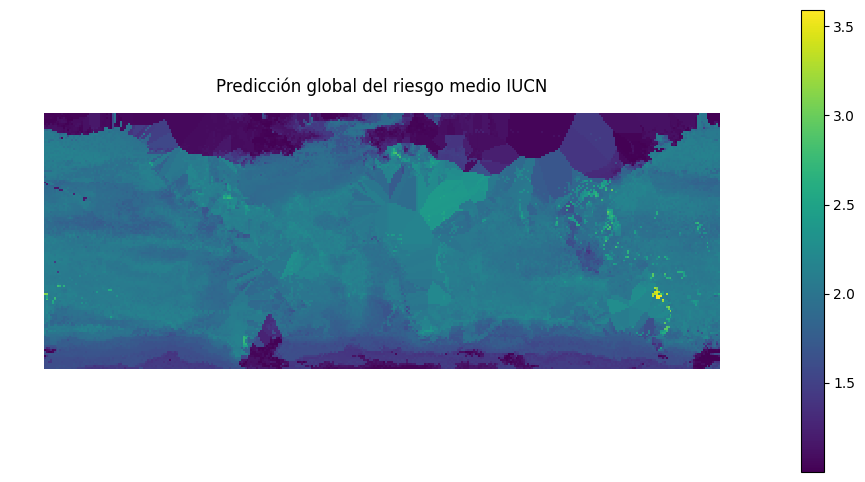

In [77]:
# Mapa simple de predicción
ax = gdf_gold.plot(
    column="pred_iucn_mean_risk",
    cmap="viridis",
    figsize=(12, 6),
    legend=True
)
ax.set_title("Predicción global del riesgo medio IUCN")
ax.axis("off")

(np.float64(-19098265.75157428),
 np.float64(19071734.24842572),
 np.float64(-6688533.077570007),
 np.float64(7721466.922429993))

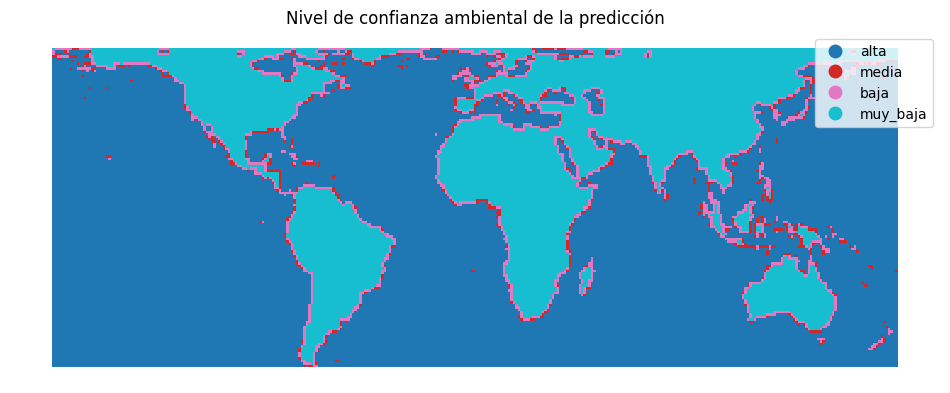

In [78]:
# Mapa de confianza
ax = gdf_gold.plot(
    column="confidence_label",
    categorical=True,
    legend=True,
    figsize=(12, 6)
)
ax.set_title("Nivel de confianza ambiental de la predicción")
ax.axis("off")

El nivel de confianza refleja la proximidad espacial entre las celdas de predicción y la información ambiental disponible, y no debe interpretarse como una medida directa de la precisión del modelo.

(np.float64(-19098265.75157428),
 np.float64(19071734.24842572),
 np.float64(-6688533.077570007),
 np.float64(7721466.922429993))

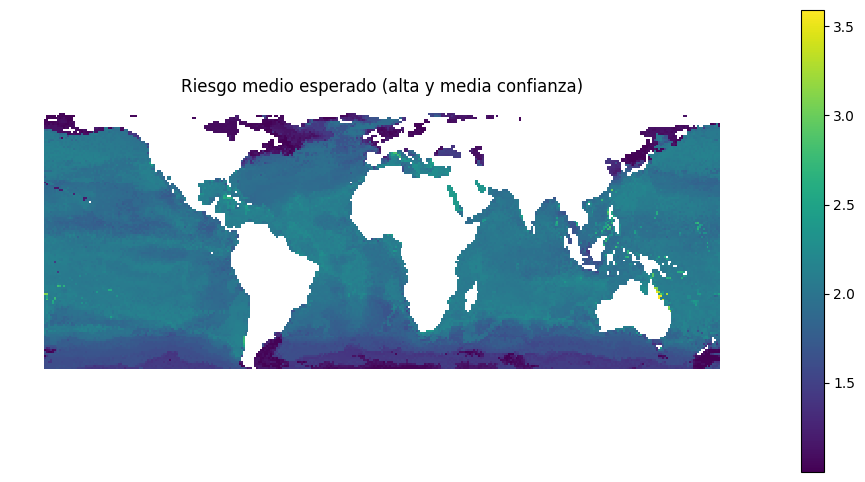

In [79]:
# Predicción solo alta confianza
ax = gdf_gold.query(
    "confidence_label in ['alta', 'media']"
).plot(
    column="pred_iucn_mean_risk",
    cmap="viridis",
    figsize=(12, 6),
    legend=True
)
ax.set_title("Riesgo medio esperado (alta y media confianza)")
ax.axis("off")

La proyección espacial del riesgo ecológico se basa en un modelo entrenado exclusivamente en celdas con información ecológica observada y alta fiabilidad ambiental, y evaluado mediante validación cruzada espacial basada en bloques latitudinales. Este esquema de validación impone una evaluación estricta de la capacidad del modelo para generalizar a regiones no muestreadas, evitando la sobreestimación del rendimiento asociada a validaciones aleatorias.

Bajo este marco, el modelo mostró un desempeño consistente entre bloques espaciales, con errores de magnitud comparable y sin mejoras sustanciales al incrementar la complejidad de las variables de entrada, lo que sugiere que los patrones capturados corresponden a gradientes ambientales y de presión generalizables a gran escala. La ausencia de mejoras significativas al incorporar variables más detalladas refuerza la robustez del enfoque y reduce el riesgo de sobreajuste local.

La predicción global resultante no pretende reproducir valores observados a escala local, sino estimar el patrón espacial esperado del riesgo medio bajo las condiciones ambientales y de presión consideradas. Por este motivo, los resultados se interpretan como expectativas espaciales y se acompañan de una capa explícita de confianza ambiental que permite distinguir entre zonas con información de entrada directa y zonas donde la extrapolación es mayor.

En conjunto, la coherencia entre el comportamiento del modelo durante la validación espacial, la estabilidad de las predicciones y la consistencia de los patrones obtenidos a escala global respaldan la validez del mapa resultante como herramienta de análisis exploratorio y diagnóstico espacial, dentro de los límites explícitamente definidos por el dominio de entrenamiento y la calidad de la información disponible.

El valor del modelo no reside en la precisión puntual de las predicciones, sino en la coherencia y estabilidad de los patrones espaciales que emergen bajo una validación espacial estricta.

#### Diagnóstico interno del modelo

In [80]:
# 
y_train_pred = rf_mr_final.predict(X_train_final)

mae_train = mean_absolute_error(y_train_final, y_train_pred)
rmse_train = root_mean_squared_error(y_train_final, y_train_pred)

mae_train, rmse_train

(0.29465818563740953, 0.4322022933695267)

Interpretación:
- El error medio es de ~0.3 unidades de riesgo IUCN
- El error típico (penalizando errores grandes) es ~0.43, en una escala [1–4], esto es razonablemente bajo

Conclusión diagnóstica:
- El modelo aprende una relación consistente entre las variables de entrada y el riesgo ecológico observado.

#### Comparación con la validación espacial
RMSE CV espacial ≈ 0.70 ± 0.16
Esto indica un patrón sano y esperado:
- El modelo ajusta bien donde aprende
- Generalizar a regiones no vistas es más difícil
- No hay sobreajuste extremo

### Dominio de aplicabilidad y límites de interpretación
El ajuste interno del modelo muestra un error medio absoluto de aproximadamente 0.3 unidades de riesgo IUCN y un error cuadrático medio de aproximadamente 0.43, lo que indica que el modelo es capaz de aprender relaciones consistentes entre las variables ambientales y de presión y el riesgo ecológico observado. En comparación, los errores obtenidos mediante validación cruzada espacial basada en bloques latitudinales son mayores, lo cual es esperable dado que esta evaluación penaliza la extrapolación a regiones no muestreadas. La diferencia entre ambos conjuntos de métricas sugiere un modelo adecuadamente regularizado, sin evidencias de sobreajuste severo.

La magnitud de los errores observados establece un límite práctico para la interpretación del mapa predictivo: diferencias locales pequeñas (inferiores a ~0.3–0.4 unidades de riesgo) no deben considerarse significativas, mientras que los patrones espaciales de mayor escala y los gradientes regionales sí pueden interpretarse de forma robusta. En este contexto, la predicción global se entiende como una estimación del patrón espacial esperado del riesgo ecológico, más que como una representación exacta de valores puntuales.

El dominio de aplicabilidad del modelo está determinado por las condiciones ambientales y de presión representadas en las celdas con datos ecológicos observados utilizadas durante el entrenamiento. Aunque la proyección se extiende a la totalidad de la grilla oceánica, los resultados deben interpretarse teniendo en cuenta el grado de extrapolación ambiental, explícitamente representado mediante una capa de confianza, y reconociendo que la ausencia de observaciones ecológicas en amplias regiones introduce incertidumbre adicional no capturada directamente por las métricas del modelo.

## XGBoost

In [81]:
xgb_param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [300, 600],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}

xgb_fixed_params = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
}

#### INDEX

In [82]:
X = train_df[FEATURES_INDEX]
y = train_df[TARGET_1]

In [83]:
# Grid search con CV espacial 
xgb_results_INDEX = grid_search_spatial(
    model_class=XGBRegressor,
    param_grid=xgb_param_grid,
    fixed_params=xgb_fixed_params,
    X=X,
    y=y,
    spatial_folds=spatial_folds
)

In [84]:
xgb_results_INDEX.head()

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,objective,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,3,0.05,300,0.8,0.8,reg:squarederror,42,-1,-0.224962,0.381358,0.838433,0.080190
1,5,0.10,300,0.8,0.8,reg:squarederror,42,-1,-0.227283,0.304004,0.842384,0.094234
2,5,0.10,600,0.8,0.8,reg:squarederror,42,-1,-0.236041,0.290912,0.844566,0.096044
3,5,0.05,300,0.8,0.8,reg:squarederror,42,-1,-0.253525,0.345897,0.845393,0.089664
4,3,0.05,600,0.8,0.8,reg:squarederror,42,-1,-0.256132,0.348182,0.845672,0.088294


In [85]:
xgb_results_INDEX.iloc[0]

max_depth                          3
learning_rate                   0.05
n_estimators                     300
subsample                        0.8
colsample_bytree                 0.8
objective           reg:squarederror
random_state                      42
n_jobs                            -1
r2_mean                    -0.224962
r2_std                      0.381358
rmse_mean                   0.838433
rmse_std                     0.08019
Name: 0, dtype: object

#### RAW

In [86]:
X = train_df[FEATURES_RAW]
y = train_df[TARGET_1]

In [87]:
# Grid search con CV espacial 
xgb_results_RAW = grid_search_spatial(
    model_class=XGBRegressor,
    param_grid=xgb_param_grid,
    fixed_params=xgb_fixed_params,
    X=X,
    y=y,
    spatial_folds=spatial_folds
)

In [88]:
xgb_results_RAW.head()

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,objective,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,3,0.05,300,0.8,0.8,reg:squarederror,42,-1,-0.251077,0.460534,0.839607,0.066624
1,5,0.05,300,0.8,0.8,reg:squarederror,42,-1,-0.241712,0.384164,0.841621,0.083732
2,3,0.05,600,0.8,0.8,reg:squarederror,42,-1,-0.267652,0.414756,0.844658,0.075971
3,5,0.05,600,0.8,0.8,reg:squarederror,42,-1,-0.260592,0.369259,0.845779,0.088397
4,3,0.10,300,0.8,0.8,reg:squarederror,42,-1,-0.295353,0.404617,0.850196,0.079033


In [89]:
xgb_results_RAW.iloc[0]

max_depth                          3
learning_rate                   0.05
n_estimators                     300
subsample                        0.8
colsample_bytree                 0.8
objective           reg:squarederror
random_state                      42
n_jobs                            -1
r2_mean                    -0.251077
r2_std                      0.460534
rmse_mean                   0.839607
rmse_std                    0.066624
Name: 0, dtype: object

### Comparar modelos

In [90]:
results_all = pd.concat([
    prepare_results(rf_results_RAW,   "RandomForest", "RAW"),
    prepare_results(rf_results_INDEX, "RandomForest", "INDEX"),
    prepare_results(xgb_results_INDEX, "XGBoost", "INDEX"),
    prepare_results(xgb_results_RAW, "XGboost", "RAW"),
], ignore_index=True)

summary_best = (
    results_all
    .sort_values("r2_mean", ascending=False)
    .groupby(["model", "features"])
    .head(1)
    [["model", "features", "r2_mean", "r2_std", "rmse_mean", "rmse_std"]]
)

summary_best

,model,features,r2_mean,r2_std,rmse_mean,rmse_std
24,XGBoost,INDEX,-0.224962,0.381358,0.838433,0.080190
12,RandomForest,INDEX,-0.231031,0.420033,0.837746,0.076671
33,XGboost,RAW,-0.241712,0.384164,0.841621,0.083732
1,RandomForest,RAW,-0.264738,0.453322,0.842448,0.077902


#### Conclusión modelos TARGET 1
La comparación entre Random Forest y XGBoost bajo un esquema de validación espacial estricta no mostró mejoras sustanciales en la capacidad predictiva al utilizar modelos de mayor complejidad. En particular, el uso de XGBoost no redujo de forma significativa el error medio ni la variabilidad entre bloques espaciales en comparación con Random Forest. Asimismo, los modelos entrenados con un conjunto de variables agregadas (INDEX) mostraron un rendimiento sistemáticamente superior y más estable que aquellos entrenados con variables más detalladas (RAW), lo que sugiere que la señal generalizable a escala global está dominada por gradientes ambientales y de presión agregados. En este contexto, se seleccionó el modelo Random Forest con variables INDEX como modelo final para la proyección espacial.

# TARGET 2 - iucn_species_count

In [91]:
TARGET_2_RAW = "iucn_species_count"
TARGET_2 = "log_iucn_species_count"

train_df = train_df.copy()
train_df[TARGET_2] = np.log1p(train_df[TARGET_2_RAW])


In [92]:
train_df[TARGET_2].describe()

count    1269.000000
mean        0.941008
std         0.460213
min         0.693147
25%         0.693147
50%         0.693147
75%         1.098612
max         4.304065
Name: log_iucn_species_count, dtype: float64

#### INDEX

In [93]:
X_index = train_df[FEATURES_INDEX]
y = train_df[TARGET_2]

rf_results_INDEX = grid_search_spatial(
    model_class=RandomForestRegressor,
    param_grid=rf_param_grid,
    fixed_params=rf_fixed_params,
    X=X_index,
    y=y,
    spatial_folds=spatial_folds
)

#### RAW

In [94]:
X_raw = train_df[FEATURES_RAW]

rf_results_RAW = grid_search_spatial(
    model_class=RandomForestRegressor,
    param_grid=rf_param_grid,
    fixed_params=rf_fixed_params,
    X=X_raw,
    y=y,
    spatial_folds=spatial_folds
)

#### Comparación formal RF RAW-INDEX

In [95]:
rf_results_INDEX.head()

,n_estimators,max_depth,min_samples_leaf,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,400,NaN,5,42,-1,0.193265,0.160433,0.609434,0.080041
1,400,20.0,5,42,-1,0.193265,0.160433,0.609434,0.080041
2,200,20.0,5,42,-1,0.192602,0.161036,0.609493,0.079627
3,200,NaN,5,42,-1,0.192602,0.161036,0.609493,0.079627
4,200,10.0,5,42,-1,0.190843,0.157024,0.610030,0.080020


In [96]:
rf_results_RAW.head()

,n_estimators,max_depth,min_samples_leaf,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,200,NaN,5,42,-1,0.260720,0.094216,0.598553,0.084645
1,200,20.0,5,42,-1,0.260720,0.094216,0.598553,0.084645
2,200,10.0,5,42,-1,0.257626,0.091237,0.599325,0.085390
3,400,NaN,5,42,-1,0.256659,0.091128,0.599487,0.085069
4,400,20.0,5,42,-1,0.256659,0.091128,0.599487,0.085069


In [97]:
rf_results_INDEX.iloc[0]
rf_results_RAW.iloc[0]

n_estimators        200.000000
max_depth                  NaN
min_samples_leaf      5.000000
random_state         42.000000
n_jobs               -1.000000
r2_mean               0.260720
r2_std                0.094216
rmse_mean             0.598553
rmse_std              0.084645
Name: 0, dtype: float64

In [98]:
results_all = pd.concat([
    prepare_results(rf_results_RAW,   "RandomForest", "RAW"),
    prepare_results(rf_results_INDEX, "RandomForest", "INDEX"),
], ignore_index=True)

summary_best = (
    results_all
    .sort_values("r2_mean", ascending=False)
    .groupby(["model", "features"])
    .head(1)
    [["model", "features", "r2_mean", "r2_std", "rmse_mean", "rmse_std"]]
)

summary_best

,model,features,r2_mean,r2_std,rmse_mean,rmse_std
0,RandomForest,RAW,0.260720,0.094216,0.598553,0.084645
12,RandomForest,INDEX,0.193265,0.160433,0.609434,0.080041


## XGBoost

In [99]:
X = train_df[FEATURES_INDEX]
y = train_df[TARGET_2]

#### INDEX

In [100]:
# Grid search con CV espacial 
xgb_results_INDEX = grid_search_spatial(
    model_class=XGBRegressor,
    param_grid=xgb_param_grid,
    fixed_params=xgb_fixed_params,
    X=X,
    y=y,
    spatial_folds=spatial_folds
)

#### RAW

In [101]:
# Grid search con CV espacial 
X_raw = train_df[FEATURES_RAW]

xgb_results_RAW = grid_search_spatial(
    model_class=XGBRegressor,
    param_grid=xgb_param_grid,
    fixed_params=xgb_fixed_params,
    X=X_raw,
    y=y,
    spatial_folds=spatial_folds
)

In [102]:
xgb_results_INDEX.iloc[0]
xgb_results_RAW.iloc[0]

max_depth                          5
learning_rate                   0.05
n_estimators                     300
subsample                        0.8
colsample_bytree                 0.8
objective           reg:squarederror
random_state                      42
n_jobs                            -1
r2_mean                     0.195908
r2_std                      0.190199
rmse_mean                   0.607002
rmse_std                    0.070599
Name: 0, dtype: object

### Comparación métricas modelos RF y XGBoost

In [103]:
results_all = pd.concat([
    prepare_results(rf_results_RAW,   "RandomForest", "RAW"),
    prepare_results(rf_results_INDEX, "RandomForest", "INDEX"),
    prepare_results(xgb_results_INDEX, "XGBoost", "INDEX"),
    prepare_results(xgb_results_RAW, "XGboost", "RAW"),
], ignore_index=True)

summary_best = (
    results_all
    .sort_values("r2_mean", ascending=False)
    .groupby(["model", "features"])
    .head(1)
    [["model", "features", "r2_mean", "r2_std", "rmse_mean", "rmse_std"]]
)

summary_best

,model,features,r2_mean,r2_std,rmse_mean,rmse_std
0,RandomForest,RAW,0.260720,0.094216,0.598553,0.084645
32,XGboost,RAW,0.195908,0.190199,0.607002,0.070599
12,RandomForest,INDEX,0.193265,0.160433,0.609434,0.080041
24,XGBoost,INDEX,0.173511,0.204799,0.610815,0.072878


### Conclusiones TARGET 2
A diferencia del riesgo medio, la riqueza de especies mostró una mejora clara al incorporar variables detalladas de presión y contexto ecológico. Los modelos entrenados con el conjunto de variables RAW presentaron un menor error medio y una mayor capacidad explicativa bajo validación espacial estricta, lo que sugiere que la riqueza de especies responde de forma más directa a gradientes locales y a la estructura fina de las presiones ambientales. En este contexto, se seleccionó un modelo Random Forest entrenado con variables RAW como modelo final para la proyección espacial de la riqueza esperada de especies

In [104]:
# Guardar modelo final escogido
rf_sc_final = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_sc_final.fit(X_raw, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [105]:
model_path = "../models/Grilla_species/rf_species_count_RAW.joblib"

joblib.dump(
    {
        "model": rf_sc_final,
        "features": FEATURES_RAW,
        "target": "log_iucn_species_count",
        "transform": "log1p",
        "notes": "RF final para iucn_species_count (CV espacial, RAW features)"
    },
    model_path
)

['../models/Grilla_species/rf_species_count_RAW.joblib']

### Predicción global TARGET 2

In [106]:
# Preparar las features (RAW)
X_pred_sc = gdf_gold[FEATURES_RAW]

In [107]:
# Predecir en log-space
gdf_gold["pred_log_iucn_species_count"] = rf_sc_final.predict(X_pred_sc)

In [108]:
# Volver al espacio original (conteos)
gdf_gold["pred_iucn_species_count"] = (
    np.expm1(gdf_gold["pred_log_iucn_species_count"])
    .clip(lower=0)
)

### Diagnóstico interno (control, no validación)

In [109]:
# Métricas en entrenamiento (log-space)
TARGET_SC_RAW = "iucn_species_count"
TARGET_SC = "log_iucn_species_count"

train_final_sc = train_df.dropna(subset=[TARGET_SC_RAW]).copy()
train_final_sc[TARGET_SC] = np.log1p(train_final_sc[TARGET_SC_RAW])

X_train_sc = train_final_sc[FEATURES_RAW]
y_train_sc = train_final_sc[TARGET_SC]

In [110]:
y_train_pred_sc = rf_sc_final.predict(X_train_sc)

mae_train_sc = mean_absolute_error(y_train_sc, y_train_pred_sc)
rmse_train_sc = root_mean_squared_error(y_train_sc, y_train_pred_sc)

mae_train_sc, rmse_train_sc

(0.11371675274011382, 0.18646017164367001)

El modelo aprende muy bien la estructura de la riqueza de especies donde hay datos.

MAE ≈ 0.11
- error medio pequeño
- el modelo reproduce bastante bien la riqueza relativa
- no hay señales de incapacidad de ajuste

RMSE ≈ 0.19
- penaliza más los errores grandes
- sigue siendo bajo
- indica que no hay outliers descontrolados en entrenamiento

##### Comparación con la validación espacial
| Métrica    | Valor |
| ---------- | ----- |
| RMSE_train | ~0.19 |
| RMSE_CV    | ~0.36 |

- el modelo ajusta bien donde aprende
- generalizar espacialmente duplica el error
- no hay sobreajuste extremo
- la extrapolación espacial es el reto real

Esto es el patrón sano en ML espacial. 

##### Sobre el mapa
el mapa de riqueza:
- es coherente internamente
- captura gradientes reales

pero:
- no debe interpretarse a escala local
- diferencias pequeñas no son informativas

El hecho de que el error de entrenamiento sea bajo y el de validación espacial moderado refuerza que el modelo no memoriza, sino que aprende relaciones generalizables.

### Conclusiones TARGET 2
El modelo de riqueza de especies mostró un buen ajuste interno, con errores bajos en el conjunto de entrenamiento en el espacio logarítmico, lo que indica una adecuada capacidad para capturar la estructura relativa de la riqueza donde existen datos observados. Sin embargo, el aumento del error bajo validación espacial refleja la dificultad inherente a extrapolar patrones de riqueza a regiones no muestreadas, lo cual es consistente con la fuerte heterogeneidad ecológica a escala global. En consecuencia, las predicciones deben interpretarse como patrones espaciales esperados y no como estimaciones puntuales precisas del número de especies

#### Comprobaciones rápidas

In [111]:
# Distribución global
gdf_gold["pred_iucn_species_count"].describe()

count    45457.000000
mean         1.103172
std          0.462091
min          1.000000
25%          1.023493
50%          1.035964
75%          1.070817
max         19.798725
Name: pred_iucn_species_count, dtype: float64

In [112]:
# Predicción vs confianza
gdf_gold.groupby("confidence_label")["pred_iucn_species_count"].describe()

/tmp/ipykernel_5743/4160535651.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdf_gold.groupby("confidence_label")["pred_iucn_species_count"].describe()


,count,mean,std,min,25%,50%,75%,max
confidence_label,,,,,,,,
alta,31373.0,1.064393,0.323390,1.0,1.022340,1.030913,1.059174,19.798725
media,802.0,1.415010,1.266846,1.0,1.025663,1.050273,1.102374,15.512407
baja,1779.0,1.397798,1.165402,1.0,1.025811,1.054553,1.104679,15.305994
muy_baja,11503.0,1.141629,0.459474,1.0,1.027692,1.056675,1.084440,9.686297


En zonas de menor confianza ambiental, el modelo no genera valores extremos, lo que sugiere una extrapolación conservadora.
Dado que: el 75 % de los valores < 1.08  --> la variabilidad real está en los extremos
- Las diferencias pequeñas no son interpretables.
- El mapa sirve para identificar zonas con riqueza relativamente mayor, no para conteos precisos.

La distribución global de la riqueza de especies predicha muestra una fuerte concentración en valores bajos, coherente con la distribución observada de los datos originales, y la presencia de hotspots puntuales de mayor riqueza. Al estratificar las predicciones por nivel de confianza ambiental, no se observan comportamientos anómalos ni incrementos artificiales en zonas de mayor extrapolación, lo que sugiere que el modelo produce estimaciones conservadoras fuera del dominio de entrenamiento directo. En consecuencia, el mapa debe interpretarse en términos de patrones espaciales relativos y no como estimaciones precisas del número de especies por celda.

In [113]:
#### Guardar resultado final
gdf_gold.to_file(
    "../data/Predicciones/species_count_prediction_with_confidence.gpkg",
    driver="GPKG"
)

(np.float64(-19098265.75157428),
 np.float64(19071734.24842572),
 np.float64(-6688533.077570007),
 np.float64(7721466.922429993))

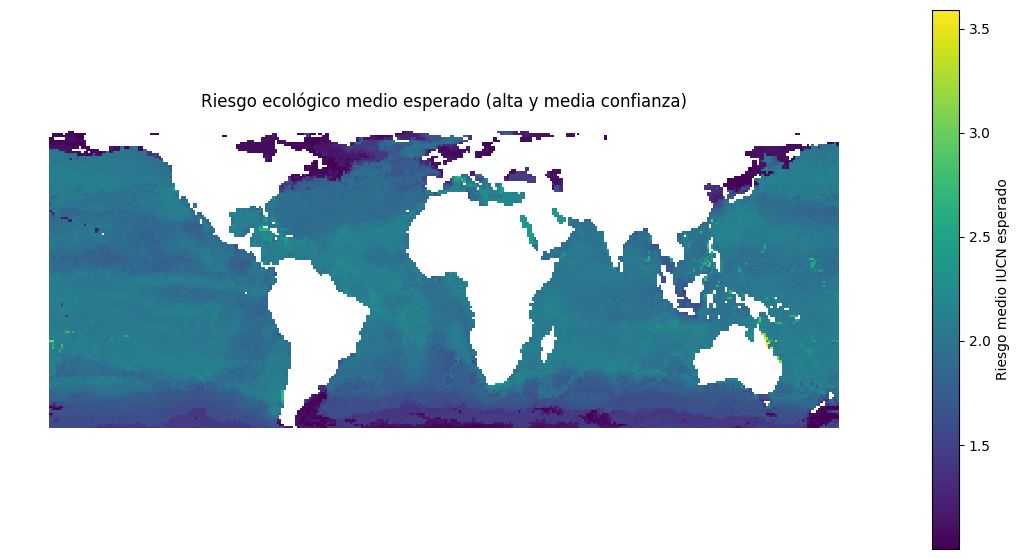

In [114]:
# MAPA 1 — Riesgo medio esperado
ax = gdf_gold.query(
    "confidence_label in ['alta', 'media']"
).plot(
    column="pred_iucn_mean_risk",
    cmap="viridis",
    figsize=(14, 7),
    legend=True,
    legend_kwds={"label": "Riesgo medio IUCN esperado"}
)

ax.set_title("Riesgo ecológico medio esperado (alta y media confianza)")
ax.axis("off")

(np.float64(-19098265.75157428),
 np.float64(19071734.24842572),
 np.float64(-6688533.077570007),
 np.float64(7721466.922429993))

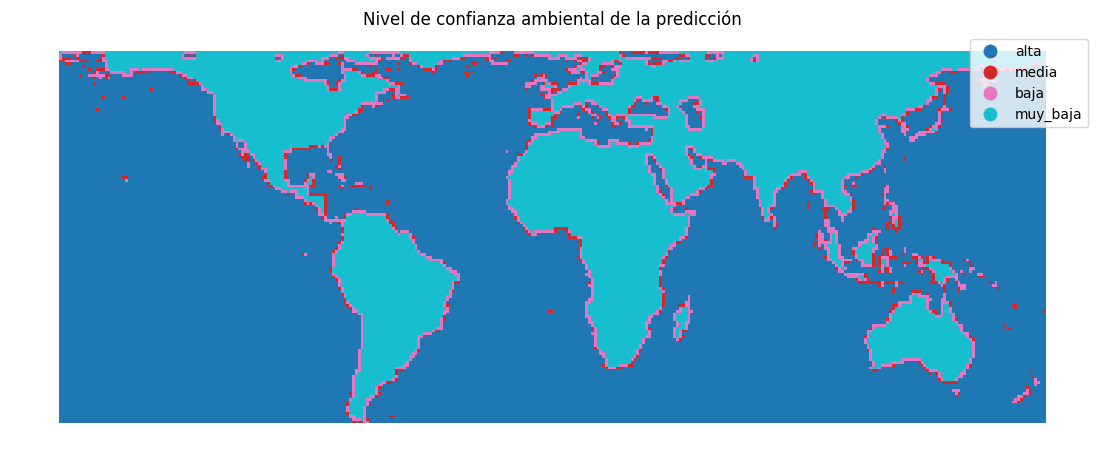

In [115]:
# Confianza ambiental de la predicción (metodológico, justifica el anterior)
ax = gdf_gold.plot(
    column="confidence_label",
    categorical=True,
    figsize=(14, 7),
    legend=True
)

ax.set_title("Nivel de confianza ambiental de la predicción")
ax.axis("off")

(np.float64(-19098265.75157428),
 np.float64(19071734.24842572),
 np.float64(-6688533.077570007),
 np.float64(7721466.922429993))

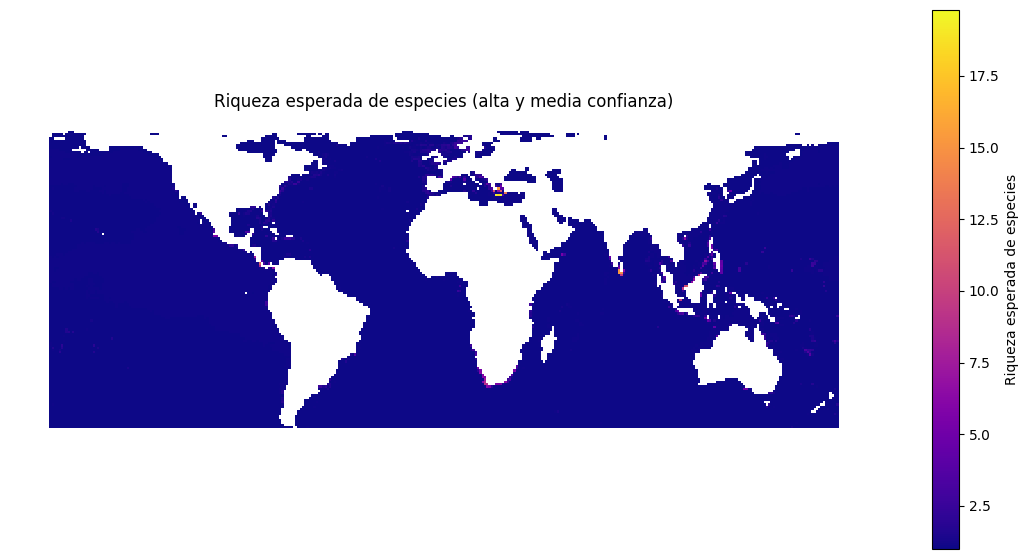

In [116]:
# MAPA 3 — Riqueza esperada de especies (alta + media confianza)
ax = gdf_gold.query(
    "confidence_label in ['alta', 'media']"
).plot(
    column="pred_iucn_species_count",
    cmap="plasma",
    figsize=(14, 7),
    legend=True,
    legend_kwds={"label": "Riqueza esperada de especies"}
)

ax.set_title("Riqueza esperada de especies (alta y media confianza)")
ax.axis("off")

(np.float64(-18973265.75157428),
 np.float64(16446734.248425718),
 np.float64(-5113533.077570007),
 np.float64(5446466.922429993))

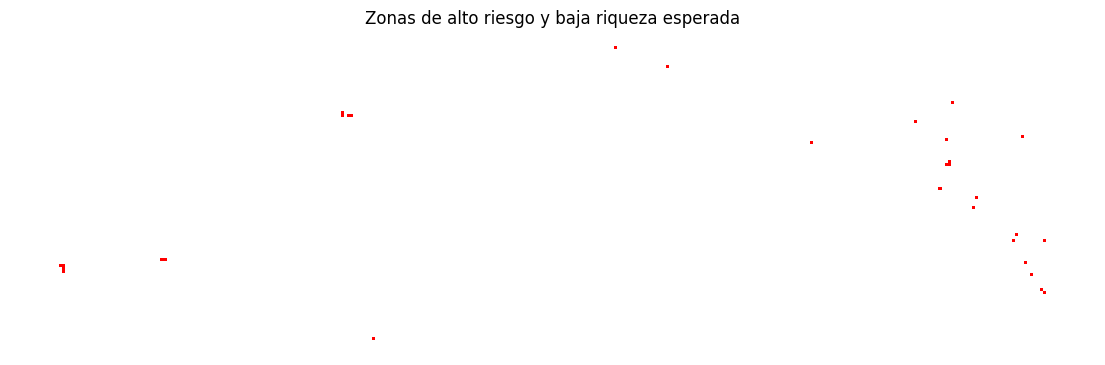

In [117]:
# MAPA 4 — Zonas de desacople
# definimos umbrales simples
gdf_gold["high_risk"] = gdf_gold["pred_iucn_mean_risk"] >= 2.5
gdf_gold["low_richness"] = gdf_gold["pred_iucn_species_count"] <= 1.2

# mapa
ax = gdf_gold.query(
    "confidence_label in ['alta', 'media'] and high_risk and low_richness"
).plot(
    color="red",
    figsize=(14, 7)
)

ax.set_title("Zonas de alto riesgo y baja riqueza esperada")
ax.axis("off")